<a href="https://colab.research.google.com/github/okparajoyf-cell/Computer-Vision-labs/blob/main/MIT8311_Lab2_Image_Classification_with_CNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Image Classification with CNNs

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Scale pixels to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add the 3rd dimension (28 x 28 x 1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(x_train.shape, x_test.shape)

(60000, 28, 28, 1) (10000, 28, 28, 1)


In [ ]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(x_train, y_train, epochs=5, batch_size=128,
                    validation_split=0.1)

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", round(test_acc, 4))

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9216 - loss: 0.2641 - val_accuracy: 0.9728 - val_loss: 0.0866
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9795 - loss: 0.0657 - val_accuracy: 0.9868 - val_loss: 0.0459
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9856 - loss: 0.0458 - val_accuracy: 0.9880 - val_loss: 0.0417
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9885 - loss: 0.0359 - val_accuracy: 0.9872 - val_loss: 0.0420
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9911 - loss: 0.0282 - val_accuracy: 0.9908 - val_loss: 0.0341
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9897 - loss: 0.0320
Test accuracy: 0.9897


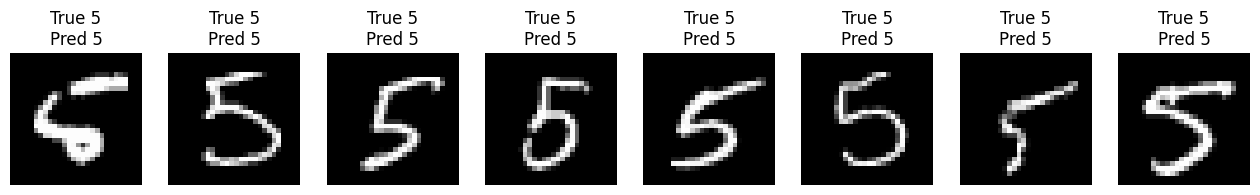

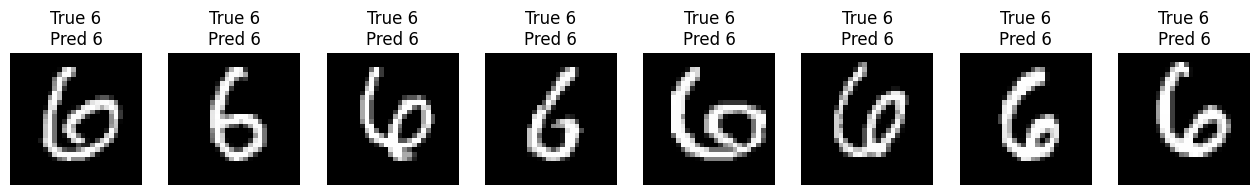

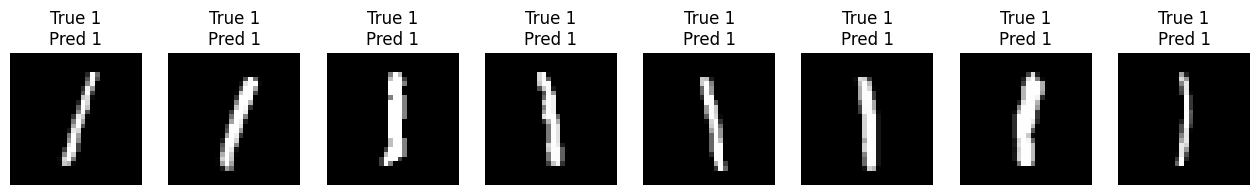

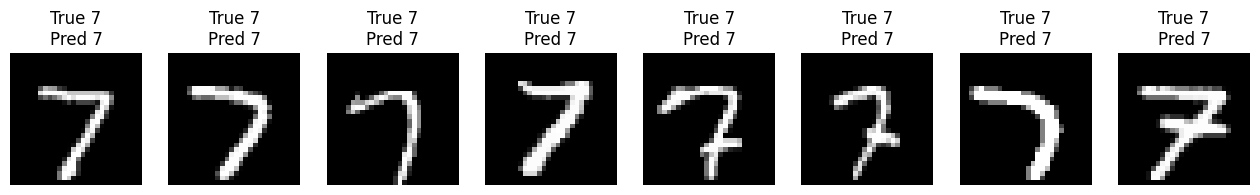

In [ ]:
def show_preds(digit, n=8):
    idx = np.where(y_test == digit)[0][:n]
    preds = model.predict(x_test[idx], verbose=0).argmax(axis=1)
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2.4))
    for ax, i, p in zip(axes, idx, preds):
        ax.imshow(x_test[i].reshape(28, 28), cmap="gray")
        ax.set_title(f"True {y_test[i]}\nPred {p}")
        ax.axis("off")
    plt.show()

for d in [5, 6, 1, 7]:
    show_preds(d)

In [ ]:
preds = model.predict(x_test, verbose=0).argmax(axis=1)
wrong = np.where(preds != y_test)[0]
print("Wrong:", len(wrong), "out of", len(y_test))

Wrong: 103 out of 10000


In [ ]:
for i in [3, 0]:   # slanted 1 and the 5 from Lab 1
    img = x_train[i].reshape(1, 28, 28, 1)
    pred = model.predict(img, verbose=0).argmax()
    print(f"True {y_train[i]} -> CNN predicts {pred}")

True 1 -> CNN predicts 1
True 5 -> CNN predicts 5


## My Observation
The CNN reached 98.92% test accuracy after 5 epochs. It got 108 out of 10,000 test images wrong. In my stress test, it correctly classified all the 5s, 6s, 1s, and 7s I checked, including slanted and blurry ones. In Lab 1, my hand-written rule failed on a slanted "1" (score 51.6, lower than the "5" at 88.0). The CNN learns edges and curves by itself, so it handles different handwriting styles better. But it is not perfect. I only checked a small sample of digits by eye.